In [17]:
import torch
import numpy as np
import pandas as pd
from transformers import\
    AutoModel, AutoModelForCausalLM, AutoTokenizer, \
    BitsAndBytesConfig, GenerationConfig, \
    TextGenerationPipeline, TextIteratorStreamer

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


In [18]:
import sys
sys.path.append('/home/fboehning/fboehning')
import beesup_llm.toolkit.display_settings

In [19]:
#https://huggingface.co/nvidia/NV-Embed-v2/discussions/37

import torch; print(f"{torch.__version__=}")
import transformers; print(f"{transformers.__version__=}")

import flash_attn; print(f"{flash_attn.__version__=}")
import accelerate; print(f"{accelerate.__version__=}") #importent!!
import bitsandbytes; print(f"{bitsandbytes.__version__=}")

torch.__version__='2.3.1'
transformers.__version__='4.43.1'
flash_attn.__version__='2.6.3'
accelerate.__version__='0.33.0'
bitsandbytes.__version__='0.45.2'


# Loading Models & Data

In [20]:
# LOAD EMBEDDING MODEL

emb_model=AutoModel.from_pretrained(
    'nvidia/NV-Embed-v2', #https://huggingface.co/nvidia/NV-Embed-v2
    device_map='auto',
    quantization_config=BitsAndBytesConfig(
        bnb_4bit_compute_dtype=torch.bfloat16,
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type='nf4',
    ),
    trust_remote_code=True
)

2025-02-21 13:32:00,839 - modeling.py - accelerate.utils.modeling - get_balanced_memory - INFO - We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [14]:
# LOAD LANGUAGE MODEL
llm_model=AutoModelForCausalLM.from_pretrained(
    'meta-llama/Meta-Llama-3.1-8B-Instruct',
    device_map="auto",
    quantization_config=BitsAndBytesConfig(
        bnb_4bit_compute_dtype=torch.bfloat16,
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type='nf4'
        )
    )

tokenizer=AutoTokenizer.from_pretrained(
    'meta-llama/Meta-Llama-3.1-8B-Instruct',
    padding_side='left',
    padding='longest',
    max_length=8192,
    pad_token='<|begin_of_text|>',
    pad_token_id=128000
    )

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
generation_config=GenerationConfig(
        return_dict_in_generate=False,
        max_time=600,
        max_new_tokens=2048,
        stop_strings=['}\n```'],
        pad_token='<|begin_of_text|>',
        pad_token_id=128000,
)

In [128]:
llm_pipe = TextGenerationPipeline(model=llm_model, tokenizer=tokenizer, streamer=TextIteratorStreamer(tokenizer, skip_prompt=True))

In [5]:
# LOAD KNOWLEDGE DATASET

chunks_df = pd.read_pickle("datasets/0006_dataset/dataset_df.pkl")
chunks_df = chunks_df.sample(1000, random_state=5).reset_index(drop=True)
chunks_df = chunks_df[['s','p','o','source_name','attr_type']]
chunks_df

,s,p,o,source_name,attr_type
0,"Bombus norvegicus (Sparre-Schneider, 1918)",Familie,Apidae,wildbienen-kataster,Attribute
1,"Andrena lagopus (Latreille, 1809)",Familie,Andrenidae,wildbienen-kataster,Attribute
2,"Lasioglossum leucopus (Kirby, 1802)",Sozialverhalten,solitär?,wildbienen-kataster,Attribute
3,"Hylaeus signatus (Panzer, 1798)",Wissenschaftlicher Name,"Hylaeus signatus (Panzer, 1798)",wildbienen-kataster,Attribute
4,"Osmia inermis (Zetterstedt, 1838)",Familie,Megachilidae,wildbienen-kataster,Attribute
...,...,...,...,...,...
995,"Hylaeus gibbus (Saunders, 1850)",Pollensammelverhalten,polylektisch (15 Familien),wildbienen-kataster,Attribute
996,"Sphecodes albilabris (Fabricius, 1793)",Umgangssprachliche Bezeichnungen,Große Blutbiene; Riesen-Blutbiene,wildbienen-kataster,Attribute
997,"Sphecodes gibbus (Linnaeus, 1758)",Sozialverhalten,parasitisch,wildbienen-kataster,Attribute
998,"Andrena suerinensis (Friese, 1884)",Umgangssprachliche Bezeichnungen,Schweriner Sandbiene,wildbienen-kataster,Attribute


# Create Beesup Question Embeddings

In [7]:
import sys
sys.path.append('/home/fboehning/fboehning')
import logging
logging.basicConfig(
    level=logging.INFO,
    #level=logging.DEBUG,
    format='%(asctime)s - %(filename)s - %(name)s - %(funcName)s - %(levelname)s - %(message)s')
TOOLKIT=[
    'beesup_llm.toolkit.llm_utils',
    'beesup_llm.toolkit.dict_utils',
    'beesup_llm.toolkit.setup_utils',
    'beesup_llm.toolkit.visualization',
    'beesup_llm.toolkit.display_settings',
    'beesup_llm.toolkit.retrieval_metrics',
]

DATASET=[
    'beesup_llm.dataset',
]

FINETUNING_PIPELINES=[
    'beesup_llm.finetuning_pipelines'
]

MODEL_PIPELINES=[
    'beesup_llm.model_pipelines'
]

INJECTION=[
    'beesup_llm.injection',
    'beesup_llm.injection.evaluator',
    'beesup_llm.injection.rag_pipeline',
    'beesup_llm.injection.taxomizer',
    'beesup_llm.injection.taxomizer_utils',
]

EXPERIMENT=[
    'beesup_llm.experiment',
]

import importlib
#import beesup_llm;

import beesup_llm.toolkit.llm_utils; from beesup_llm.toolkit.llm_utils import *
import beesup_llm.toolkit.dict_utils; from beesup_llm.toolkit.dict_utils import *
import beesup_llm.toolkit.setup_utils; from beesup_llm.toolkit.setup_utils import *
import beesup_llm.toolkit.visualization; from beesup_llm.toolkit.visualization import *
import beesup_llm.toolkit.display_settings; from beesup_llm.toolkit.display_settings import *
import beesup_llm.toolkit.retrieval_metrics; from beesup_llm.toolkit.retrieval_metrics import *

import beesup_llm.dataset; from beesup_llm.dataset import *

import beesup_llm.injection; from beesup_llm.injection import *
import beesup_llm.injection.evaluator; from beesup_llm.injection.evaluator import *
import beesup_llm.injection.rag_pipeline; from beesup_llm.injection.rag_pipeline import *
import beesup_llm.injection.taxomizer_utils; from beesup_llm.injection.taxomizer_utils import * 

def reimport(pathlist=TOOLKIT+DATASET+MODEL_PIPELINES+INJECTION):

    pathlist = ['beesup_llm'] + pathlist

    for module_path in pathlist:
        if module_path in sys.modules:
            # Reload if the module is already imported
            importlib.reload(sys.modules[module_path])
        else:

            importlib.import_module(module_path)
            # Import the module or submodule for the first time
            globals()[module_path.split('.')[0]] = importlib.import_module(module_path)

        module = sys.modules[module_path]
        globals().update({name: getattr(module, name) for name in dir(module) if not name.startswith('_')})

import logging
def set_info():
    logger = logging.getLogger('beesup_llm')
    logger.setLevel(logging.INFO)
    logging.getLogger().setLevel(logging.INFO)

def set_debug():
    logger = logging.getLogger('beesup_llm')
    logger.setLevel(logging.DEBUG)
    logging.getLogger().setLevel(logging.DEBUG)

set_info()
reimport()

In [34]:
def add_emb_col(
        df,
        emb_model,
        col_to_embed='question',
        batch_size=32,
        instruction="Given a question, retrieve passages that answer the question",
        verbose=False,
        ):

    embs=[]
    for i in range(0, len(df), batch_size):

        chunk_batch = df[i:i+batch_size][col_to_embed].to_list()
        emb_batch = emb_model.encode(chunk_batch, instruction=instruction)
        emb_batch = [emb.cpu().numpy() for emb in emb_batch] # convert to numpy array/ move to cpu
        embs.extend(emb_batch)
        torch.cuda.empty_cache()

        if verbose: print(f"{i+len(emb_batch)}/{len(df)}"+25*" ", end="\r")

    df[f'{col_to_embed}_emb']=embs

    return df

In [35]:
evaluators_df=Evaluator.get_overview(keypaths=['subtype','remarks','n_rows'])
evaluators_df=evaluators_df[
    (evaluators_df.id >= 3)
]
evaluators_df

,id,name,subtype,remarks,n_rows
2,3,0003_llm_evaluator,mcq,"wildbee mcq questions, mainly generated by gpt...",105.0
3,4,0004_llm_evaluator,mcq,"mmlu questions from cais/mmlu testset, 100 row...",100.0
4,5,0005_llm_evaluator,qdq,qdq questions only for 'Wissenschaftlicher Nam...,27.0
5,6,0006_llm_evaluator,ffq,free form questions from gpt-4o,5.0


In [36]:
for _,row in evaluators_df.iterrows():
    evaluator=Evaluator.from_ref(row.id)
    evaluator_df=evaluator.df

    if 'question_emb' in evaluator_df.columns: continue

    evaluator_df=add_emb_col(
        evaluator_df,
        emb_model,
        col_to_embed='question',
        batch_size=32,
        verbose=True,
        instruction="Given a question, retrieve passages that answer the question", 
        )
    evaluator_df.to_pickle(f"{evaluator._path}/df.pkl")

    

2025-02-21 13:45:37,295 - __init__.py - beesup_llm - __init__ - INFO - 0003_LLM_EVALUATOR initialised


2025-02-21 13:45:39,515 - __init__.py - beesup_llm - __init__ - INFO - 0004_LLM_EVALUATOR initialised


2025-02-21 13:45:46,213 - __init__.py - beesup_llm - __init__ - INFO - 0005_LLM_EVALUATOR initialised


2025-02-21 13:45:46,854 - __init__.py - beesup_llm - __init__ - INFO - 0006_LLM_EVALUATOR initialised


In [33]:
evaluator_df

,sidx,kidx,tidx,add_kidc,emb_col,question,answer,question_emb
0,0,3028,2657,[2968],spo,Woran kann man die Männchen und Weibchen von N...,Die Männchen von Nomada guttulata sehen den We...,"[0.00084716425, -0.007120987, 0.016879555, -0...."
1,1,2022,1783,"[2024, 2021]",s,Wie unterscheiden sich die Männchen und Weibch...,Die Weibchen von Hylaeus nigritus haben eine d...,"[0.012036505, -0.006811632, -0.011632796, -0.0..."
2,2,222,194,[],so,Warum werden die Arten der Untergattung Cnemid...,Die Arten der Untergattung Cnemidandrena werde...,"[-0.00030259686, -0.0062329257, 0.01872356, -0..."
3,3,2943,2582,"[1924, 814]",p,Zu welcher Familie gehört die Bienenart Nomada...,Nomada femoralis gehört zur Familie der Apidae.,"[0.004638728, -0.012345675, 0.023242734, 0.013..."
4,4,3284,2882,"[3298, 3194, 2987]",po,Welche Wirtsarten parasitiert Nomada trapezifo...,Nomada trapeziformis parasitiert vermutlich An...,"[0.011890685, -0.020880347, 0.0090242885, 0.00..."


In [23]:
evaluator._path

'/home/fboehning/fboehning/injection_lab/llm_evaluators/0006_llm_evaluator'

In [14]:
evaluator_df

,sidx,kidx,tidx,add_kidc,emb_col,question,answer
0,0,3028,2657,[2968],spo,Woran kann man die Männchen und Weibchen von N...,Die Männchen von Nomada guttulata sehen den We...
1,1,2022,1783,"[2024, 2021]",s,Wie unterscheiden sich die Männchen und Weibch...,Die Weibchen von Hylaeus nigritus haben eine d...
2,2,222,194,[],so,Warum werden die Arten der Untergattung Cnemid...,Die Arten der Untergattung Cnemidandrena werde...
3,3,2943,2582,"[1924, 814]",p,Zu welcher Familie gehört die Bienenart Nomada...,Nomada femoralis gehört zur Familie der Apidae.
4,4,3284,2882,"[3298, 3194, 2987]",po,Welche Wirtsarten parasitiert Nomada trapezifo...,Nomada trapeziformis parasitiert vermutlich An...


# Embed the knowledge

In [6]:
# creating text chunks from subject, predicate and object
chunks_df['chunk'] = chunks_df.apply(lambda x: "{s}\t{p}\t{o}".format(**x), axis=1)
chunks_df.head(3)

,s,p,o,source_name,attr_type,chunk
0,"Bombus norvegicus (Sparre-Schneider, 1918)",Familie,Apidae,wildbienen-kataster,Attribute,"Bombus norvegicus (Sparre-Schneider, 1918)\tFa..."
1,"Andrena lagopus (Latreille, 1809)",Familie,Andrenidae,wildbienen-kataster,Attribute,"Andrena lagopus (Latreille, 1809)\tFamilie\tAn..."
2,"Lasioglossum leucopus (Kirby, 1802)",Sozialverhalten,solitär?,wildbienen-kataster,Attribute,"Lasioglossum leucopus (Kirby, 1802)\tSozialver..."


In [8]:
!nvidia-smi

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Thu Feb 20 09:49:34 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.127.05             Driver Version: 550.127.05     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     Off |   00000000:D2:00.0 Off |                    0 |
|  0%   53C    P0            114W /  300W |   41545MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [25]:
torch.cuda.empty_cache()

In [7]:
# generate embeddings batchwise

batch_size=32

embs=[]
for i in range(0, len(chunks_df), batch_size):

    chunk_batch = chunks_df[i:i+batch_size]['chunk'].to_list()
    emb_batch = emb_model.encode(chunk_batch)
    emb_batch = [emb.cpu().numpy() for emb in emb_batch] # convert to numpy array/ move to cpu
    embs.extend(emb_batch)
    torch.cuda.empty_cache()
    print(f"{i+len(emb_batch)}/{len(chunks_df)}"+25*" ", end="\r")

chunks_df['emb']=embs
chunks_df.to_pickle("rag_chunks_df.pkl")
chunks_df

,s,p,o,source_name,attr_type,chunk,emb
0,"Bombus norvegicus (Sparre-Schneider, 1918)",Familie,Apidae,wildbienen-kataster,Attribute,"Bombus norvegicus (Sparre-Schneider, 1918)\tFa...","[0.013086618, -0.022352546, 0.0034646555, 0.00..."
1,"Andrena lagopus (Latreille, 1809)",Familie,Andrenidae,wildbienen-kataster,Attribute,"Andrena lagopus (Latreille, 1809)\tFamilie\tAn...","[-0.007550279, -0.036157347, -0.0011322917, 0...."
2,"Lasioglossum leucopus (Kirby, 1802)",Sozialverhalten,solitär?,wildbienen-kataster,Attribute,"Lasioglossum leucopus (Kirby, 1802)\tSozialver...","[-0.013629736, -0.013158963, 0.025674935, -0.0..."
3,"Hylaeus signatus (Panzer, 1798)",Wissenschaftlicher Name,"Hylaeus signatus (Panzer, 1798)",wildbienen-kataster,Attribute,"Hylaeus signatus (Panzer, 1798)\tWissenschaftl...","[0.009372441, -0.00028121198, 0.0098856855, -0..."
4,"Osmia inermis (Zetterstedt, 1838)",Familie,Megachilidae,wildbienen-kataster,Attribute,"Osmia inermis (Zetterstedt, 1838)\tFamilie\tMe...","[-0.00827481, -0.021447664, 0.0060573258, 0.02..."
...,...,...,...,...,...,...,...
995,"Hylaeus gibbus (Saunders, 1850)",Pollensammelverhalten,polylektisch (15 Familien),wildbienen-kataster,Attribute,"Hylaeus gibbus (Saunders, 1850)\tPollensammelv...","[0.005009956, -0.011512884, 0.017175572, 0.002..."
996,"Sphecodes albilabris (Fabricius, 1793)",Umgangssprachliche Bezeichnungen,Große Blutbiene; Riesen-Blutbiene,wildbienen-kataster,Attribute,"Sphecodes albilabris (Fabricius, 1793)\tUmgang...","[0.0013099256, 0.01285077, 0.013053347, 0.0006..."
997,"Sphecodes gibbus (Linnaeus, 1758)",Sozialverhalten,parasitisch,wildbienen-kataster,Attribute,"Sphecodes gibbus (Linnaeus, 1758)\tSozialverha...","[-0.0021326197, 0.0005152508, 0.018687356, 0.0..."
998,"Andrena suerinensis (Friese, 1884)",Umgangssprachliche Bezeichnungen,Schweriner Sandbiene,wildbienen-kataster,Attribute,"Andrena suerinensis (Friese, 1884)\tUmgangsspr...","[0.00014077175, -0.018048609, 0.004513744, 0.0..."


In [8]:
from sklearn.metrics.pairwise import cosine_similarity

def get_ranking_df(question, chunks_df, emb_model):

    chunk_embs=np.vstack(chunks_df['emb'].values)
    question_emb=emb_model.encode([question], instruction="Given a question, retrieve passages that answer the question")[0].cpu().numpy()

    ranking_df=chunks_df.copy()
    ranking_df['score']=cosine_similarity(question_emb.reshape(1,-1),chunk_embs)[0]
    ranking_df=ranking_df.sort_values('score', ascending=False)
    
    return ranking_df



In [41]:
chunks_df=pd.read_pickle("rag_chunks_df.pkl")
chunks_df['n_tokns'] = chunks_df['chunk'].apply(lambda x: len(llm_pipe.tokenizer(x)['input_ids']))

In [40]:
ranking_df = get_ranking_df("Welche Wildbienen leben solitär?", chunks_df, emb_model)
ranking_df


,s,p,o,source_name,attr_type,chunk,emb,n_tokns,score
360,"Hylaeus punctatus (Brullé, 1832)",Sozialverhalten,solitär,wildbienen-kataster,Attribute,"Hylaeus punctatus (Brullé, 1832)\tSozialverhal...","[-0.0071949363, -0.011734155, 0.021790573, 0.0...",23,0.692339
465,"Hylaeus pectoralis (Förster, 1871)",Sozialverhalten,solitär,wildbienen-kataster,Attribute,"Hylaeus pectoralis (Förster, 1871)\tSozialverh...","[-0.00526836, -0.019533604, 0.032875914, 0.010...",24,0.686803
755,"Hylaeus dilatatus (Kirby, 1802)",Sozialverhalten,solitär,wildbienen-kataster,Attribute,"Hylaeus dilatatus (Kirby, 1802)\tSozialverhalt...","[-0.0051630097, -0.025903935, 0.032405652, 0.0...",23,0.681368
920,"Hylaeus confusus (Nylander, 1852)",Sozialverhalten,solitär,wildbienen-kataster,Attribute,"Hylaeus confusus (Nylander, 1852)\tSozialverha...","[-0.01150042, -0.011889807, 0.029319182, 0.010...",23,0.676459
18,"Lasioglossum villosulum (Kirby, 1802)",Sozialverhalten,solitär,wildbienen-kataster,Attribute,"Lasioglossum villosulum (Kirby, 1802)\tSozialv...","[-0.0072044046, -0.017175661, 0.03316266, 0.00...",24,0.669812
...,...,...,...,...,...,...,...,...,...
744,"Andrena pusilla (Pérez, 1903)",Familie,Andrenidae,wildbienen-kataster,Attribute,"Andrena pusilla (Pérez, 1903)\tFamilie\tAndren...","[0.0011739604, -0.03174263, 0.008014706, 0.035...",21,0.362745
324,"Panurgus calcaratus (Scopoli, 1763)",Familie,Andrenidae,wildbienen-kataster,Attribute,"Panurgus calcaratus (Scopoli, 1763)\tFamilie\t...","[-0.014058372, -0.032679353, 0.0078032496, 0.0...",23,0.362574
486,"Eucera longicornis (Linnaeus, 1758)",Familie,Apidae,wildbienen-kataster,Attribute,"Eucera longicornis (Linnaeus, 1758)\tFamilie\t...","[0.014357883, -0.02746611, 0.003907769, 0.0120...",22,0.353819
772,"Systropha curvicornis (Scopoli, 1770)",Familie,Halictidae,wildbienen-kataster,Attribute,"Systropha curvicornis (Scopoli, 1770)\tFamilie...","[0.006976382, -0.035812102, 0.01754013, 0.0159...",25,0.352470


In [43]:
# CHUNK SELECTION

def select_by_tokn_limit(ranking_df, limit=500):
    ranking_df=ranking_df.copy()
    assert 'n_tokns' in ranking_df.columns, "n_tokns column missing in ranking_df"

    ranking_df['n_tokns_cumsum'] = ranking_df['n_tokns'].cumsum()
    return (ranking_df['n_tokns_cumsum']<limit).to_list()

def select_by_char_limit(ranking_df, limit=500):
    assert 'n_chars' in ranking_df.columns, "n_chars column missing in ranking_df"

    ranking_df['n_chars_cumsum'] = ranking_df['n_chars'].cumsum()
    return (ranking_df['n_chars_cumsum']<limit).to_list()

from kneed import KneeLocator
def select_by_knee_score(ranking_df):
    ranking_df=ranking_df.copy()
    assert 'score' in ranking_df.columns, "score column missing in ranking_df"

    knee_index = KneeLocator(list(range(len(ranking_df))), ranking_df['score'], curve="convex", direction="decreasing").knee
    knee_score = ranking_df.iloc[knee_index]['score']

    return (ranking_df['score']>=knee_score).to_list()


ranking_df['fit_tokn_limit'] = select_by_tokn_limit(ranking_df, limit=500)
ranking_df['fit_knee_score'] = select_by_knee_score(ranking_df)
ranking_df


,s,p,o,source_name,attr_type,chunk,emb,n_tokns,score,fit_tokn_limit,fit_knee_score
360,"Hylaeus punctatus (Brullé, 1832)",Sozialverhalten,solitär,wildbienen-kataster,Attribute,"Hylaeus punctatus (Brullé, 1832)\tSozialverhal...","[-0.0071949363, -0.011734155, 0.021790573, 0.0...",23,0.692339,True,True
465,"Hylaeus pectoralis (Förster, 1871)",Sozialverhalten,solitär,wildbienen-kataster,Attribute,"Hylaeus pectoralis (Förster, 1871)\tSozialverh...","[-0.00526836, -0.019533604, 0.032875914, 0.010...",24,0.686803,True,True
755,"Hylaeus dilatatus (Kirby, 1802)",Sozialverhalten,solitär,wildbienen-kataster,Attribute,"Hylaeus dilatatus (Kirby, 1802)\tSozialverhalt...","[-0.0051630097, -0.025903935, 0.032405652, 0.0...",23,0.681368,True,True
920,"Hylaeus confusus (Nylander, 1852)",Sozialverhalten,solitär,wildbienen-kataster,Attribute,"Hylaeus confusus (Nylander, 1852)\tSozialverha...","[-0.01150042, -0.011889807, 0.029319182, 0.010...",23,0.676459,True,True
18,"Lasioglossum villosulum (Kirby, 1802)",Sozialverhalten,solitär,wildbienen-kataster,Attribute,"Lasioglossum villosulum (Kirby, 1802)\tSozialv...","[-0.0072044046, -0.017175661, 0.03316266, 0.00...",24,0.669812,True,True
...,...,...,...,...,...,...,...,...,...,...,...
744,"Andrena pusilla (Pérez, 1903)",Familie,Andrenidae,wildbienen-kataster,Attribute,"Andrena pusilla (Pérez, 1903)\tFamilie\tAndren...","[0.0011739604, -0.03174263, 0.008014706, 0.035...",21,0.362745,False,False
324,"Panurgus calcaratus (Scopoli, 1763)",Familie,Andrenidae,wildbienen-kataster,Attribute,"Panurgus calcaratus (Scopoli, 1763)\tFamilie\t...","[-0.014058372, -0.032679353, 0.0078032496, 0.0...",23,0.362574,False,False
486,"Eucera longicornis (Linnaeus, 1758)",Familie,Apidae,wildbienen-kataster,Attribute,"Eucera longicornis (Linnaeus, 1758)\tFamilie\t...","[0.014357883, -0.02746611, 0.003907769, 0.0120...",22,0.353819,False,False
772,"Systropha curvicornis (Scopoli, 1770)",Familie,Halictidae,wildbienen-kataster,Attribute,"Systropha curvicornis (Scopoli, 1770)\tFamilie...","[0.006976382, -0.035812102, 0.01754013, 0.0159...",25,0.352470,False,False


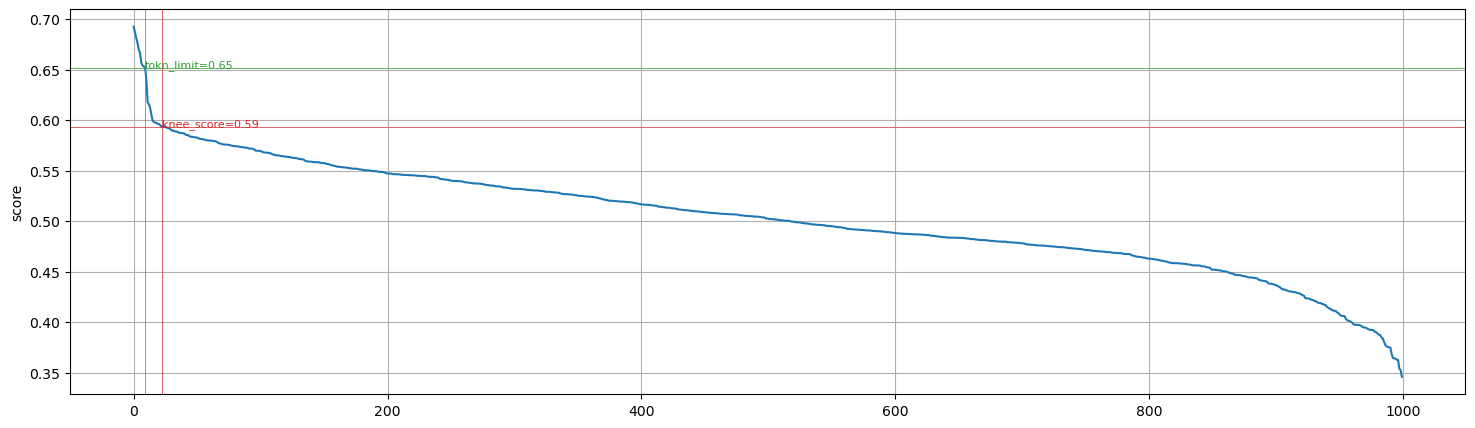

In [64]:
def plot_ranking(ranking_df):

    import matplotlib
    from matplotlib import pyplot as plt

    plt.figure(figsize=(18, 5))
    plt.plot(range(0,len(ranking_df)),ranking_df['score'])

    selector_cols=[c for c in ranking_df.columns if c.startswith('fit_')]
    for i,col in enumerate(selector_cols):
        color=matplotlib.colormaps["tab10"].colors[i+2]
        idx=ranking_df[col].to_list().index(False)-1
        val=ranking_df.iloc[idx]['score']

        plt.axhline(y=val, color=color, linestyle='-', linewidth=0.5)
        plt.axvline(x=idx, color=color, linestyle='-', linewidth=0.5)
        plt.text(idx, val, f"{col.replace('fit_','')}={val:.2f}", color=color, fontsize=8)


    plt.ylabel('score')
    plt.grid(True)
    plt.show()

plot_ranking(ranking_df)


In [88]:
# Selector Classes: Used to select chunks presented to the language model
class fit_tokn_limit:
    def __init__(self, limit=500):
        self.limit=limit
    
    def __call__(self, ranking_df):
        ranking_df=ranking_df.copy()
        assert 'n_tokns' in ranking_df.columns, "n_tokns column missing in ranking_df"
        ranking_df['n_tokns_cumsum'] = ranking_df['n_tokns'].cumsum()
        return (ranking_df['n_tokns_cumsum']<self.limit).to_list()

from kneed import KneeLocator
class fit_knee_score:
    def __call__(self, ranking_df):
        ranking_df=ranking_df.copy()
        assert 'score' in ranking_df.columns, "score column missing in ranking_df"

        knee_index = KneeLocator(list(range(len(ranking_df))), ranking_df['score'], curve="convex", direction="decreasing").knee
        knee_score = ranking_df.iloc[knee_index]['score']

        return (ranking_df['score']>=knee_score).to_list()


In [121]:
def get_rag_prompt_messages(question, briefing_df):

    prompt_messages=[]

    #system message
    prompt_messages.append(dict(role='system', content=''))
    prompt_messages[-1]['content']+="""
You are an AI assistant with access to relevant knowledge chunks. \
Your goal is to answer the user's question **strictly based on the provided context**. \
If the answer is not present in the context, state **"I don’t know based on the provided information." \
** Do **not** attempt to answer using outside knowledge.
""".strip()
    
    #user message with briefing chunks + question
    
    prompt_messages.append(dict(role='user', content=''))
    prompt_messages[-1]['content']+="### Context:\n"
    for _,row in briefing_df.iterrows():
        prompt_messages[-1]['content']+=f"{row['chunk']}\n\n"

    prompt_messages[-1]['content']+="### User Question:\n"
    prompt_messages[-1]['content']+=f"{question}"

    return prompt_messages

In [167]:
from threading import Thread

class RAGPipeline(object):
    type='rag_pipeline'

    def __init__(
            self,
            llm_pipe: TextGenerationPipeline,
            emb_model: AutoModel,
            chunks_df: pd.DataFrame, # requires columns 'emb' that holds the embedding vectors and 'chunk' that holds text passages
            selectors: list = [fit_tokn_limit(limit=800), fit_knee_score()]
            ):

        self.llm_pipe = llm_pipe
        self.emb_model = emb_model
        self.chunks_df = chunks_df
        self.selectors = selectors
        self.add_chunk_features()

    def add_chunk_features(self):
        
        chunks_df=self.chunks_df.copy()
        
        if 'n_tokens' not in chunks_df.columns:
            chunks_df['n_tokens'] = chunks_df['chunk'].apply(lambda x: len(self.llm_pipe.tokenizer(x)['input_ids']))

        if 'n_chars' not in chunks_df.columns:
            chunks_df['n_chars'] = chunks_df['chunk'].apply(len)
        
        self.chunks_df = chunks_df
        return
        
    def get_ranking_df(self, question: str):

        chunk_embs=np.vstack(self.chunks_df['emb'].values)
        question_emb=self.emb_model.encode([question], instruction="Given a question, retrieve passages that answer the question")[0].cpu().numpy()

        ranking_df=self.chunks_df.copy()
        ranking_df['score']=cosine_similarity(question_emb.reshape(1,-1),chunk_embs)[0]
        ranking_df=ranking_df.sort_values('score', ascending=False)

        return ranking_df
        
    def get_response(self, question: str, briefing_df: pd.DataFrame, stream=True):

        generation_config=GenerationConfig(
                return_dict_in_generate=False,
                max_time=60, #seconds
                max_new_tokens=1000,
                pad_token='<|begin_of_text|>',
                pad_token_id=128000,
        )

        prompt_messages = get_rag_prompt_messages(question, briefing_df)

        if stream:
            streamer = TextIteratorStreamer(self.llm_pipe.tokenizer, skip_prompt=True)
            llm_pipe = TextGenerationPipeline(model=self.llm_pipe.model, tokenizer=self.llm_pipe.tokenizer, streamer=streamer)

            streamer_thread=Thread(
                target=llm_pipe,
                kwargs=dict(
                    text_inputs=prompt_messages,
                    tokenizer=llm_pipe.tokenizer,
                    generation_config=generation_config,
                    return_full_text=False,
                    clean_up_tokenization_spaces=True
                    )
                )

            try:
                streamer_thread.start()
                response=""
                for new_token in streamer:
                    if new_token in llm_pipe.tokenizer.special_tokens_map.values(): continue
                    response+=new_token
                    print(new_token,end='',flush=True)
                    
                streamer_thread.join()
            
            except Exception as e:
                print(f'{e}')
                streamer_thread.join()
                torch.cuda.empty_cache()
            
            del streamer
            del llm_pipe

        else:
            response = self.llm_pipe(
                prompt_messages,
                generation_config=generation_config,
                return_full_text=False,
                clean_up_tokenization_spaces=True
                )[0]['generated_text']

        return response

    def __call__(self, question: str, stream=True, verbose=False):

        ranking_df = self.get_ranking_df(question)

        for selector in self.selectors:
            ranking_df[selector.__class__.__name__] = selector(ranking_df)
        
        briefing_df=ranking_df[ranking_df[[s.__class__.__name__ for s in self.selectors]].all(axis=1)].copy()

        self._recent_ranking_df = ranking_df
        self._recent_briefing_df = briefing_df

        if verbose:
            plot_ranking(ranking_df)
            display(briefing_df)
            display(ranking_df.iloc[len(briefing_df):len(briefing_df)+3]) # also show some non-selected chunks
        
        response=self.get_response(question, briefing_df, stream=stream)

        return response
  

In [84]:
selector=fit_tokn_limit(limit=800)
selector.__class__.__name__

'fit_tokn_limit'

In [168]:
rag_pipe=RAGPipeline(
    llm_pipe=llm_pipe,
    emb_model=emb_model,
    chunks_df=chunks_df,
    selectors=[fit_tokn_limit(limit=800), fit_knee_score()]
    )

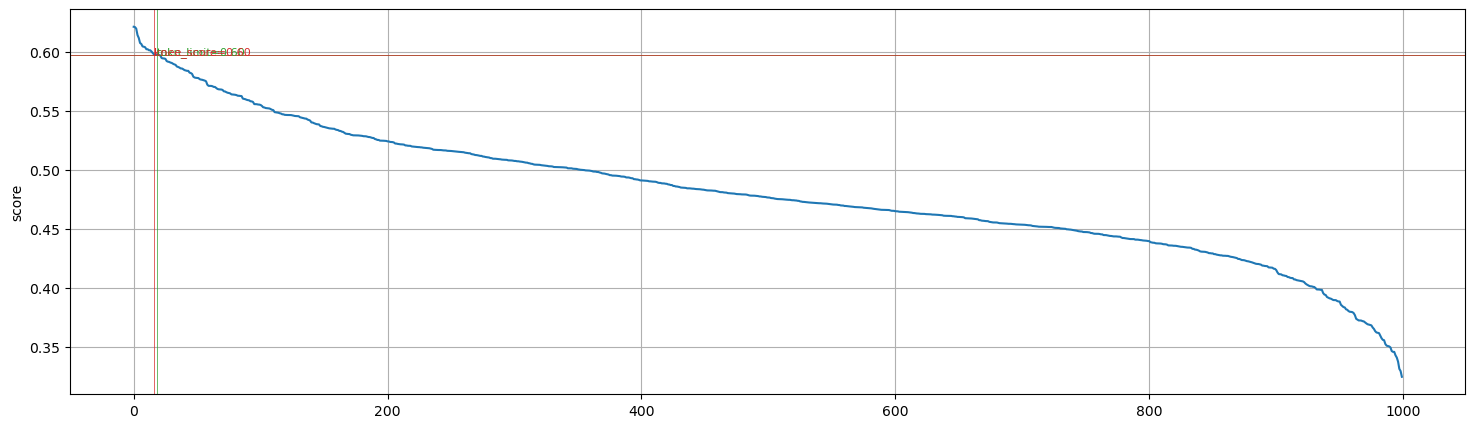

,s,p,o,source_name,attr_type,chunk,emb,n_tokns,n_tokens,n_chars,score,fit_tokn_limit,fit_knee_score
407,"Hylaeus taeniolatus (Förster, 1871)",Nistweise,hypergäisch-vorhandene Hohlräume,wildbienen-kataster,Attribute,"Hylaeus taeniolatus (Förster, 1871)\tNistweise...","[0.00691936, -0.009391923, 0.019492144, 0.0060...",35,35,78,0.621326,True,True
672,"Bombus terrestris (Linnaeus, 1758)",Nistweise,endogäisch-vorhandene Hohlräume,wildbienen-kataster,Attribute,"Bombus terrestris (Linnaeus, 1758)\tNistweise\...","[0.0028762883, -0.016068175, 0.021032931, -0.0...",31,31,76,0.621076,True,True
265,"Andrena ovatula (Kirby, 1802)",Nistweise,endogäisch-selbstgegrabene Hohlräume,wildbienen-kataster,Attribute,"Andrena ovatula (Kirby, 1802)\tNistweise\tendo...","[-0.007783524, -0.01819142, 0.017437784, 0.015...",32,32,76,0.619755,True,True
575,"Colletes cunicularius (Linnaeus, 1761)",Nistweise,endogäisch-selbstgegrabene Hohlräume,wildbienen-kataster,Attribute,"Colletes cunicularius (Linnaeus, 1761)\tNistwe...","[-0.012391122, -0.015684582, 0.026838675, 0.00...",34,34,85,0.614323,True,True
986,"Hylaeus communis (Nylander, 1852)",Nestbau,Diese Bienenart nistet in vorhandenen Hohlräum...,wikipedia,Text,"Hylaeus communis (Nylander, 1852)\tNestbau\tDi...","[0.01832169, -0.0056690997, 0.020934114, 0.001...",183,183,500,0.611867,True,True
500,"Halictus submediterraneus (Pauly, 2015)",Nistweise,endogäisch-selbstgegrabene Hohlräume,wildbienen-kataster,Attribute,"Halictus submediterraneus (Pauly, 2015)\tNistw...","[-0.0014072992, -0.0035272997, 0.028345464, 0....",35,35,86,0.607623,True,True
163,"Andrena praecox (Scopoli, 1763)",Nistweise,endogäisch-selbstgegrabene Hohlräume,wildbienen-kataster,Attribute,"Andrena praecox (Scopoli, 1763)\tNistweise\ten...","[-0.01091138, -0.022895876, 0.011888469, 0.021...",33,33,78,0.606750,True,True
376,"Andrena tscheki (Morawitz, 1872)",Nistweise,endogäisch-selbstgegrabene Hohlräume,wildbienen-kataster,Attribute,"Andrena tscheki (Morawitz, 1872)\tNistweise\te...","[-0.0074826013, -0.01205685, 0.029016376, 0.02...",33,33,79,0.604674,True,True
957,"Dasypoda hirtipes (Fabricius, 1793)",Nistweise,endogäisch-selbstgegrabene Hohlräume,wildbienen-kataster,Attribute,"Dasypoda hirtipes (Fabricius, 1793)\tNistweise...","[-0.011036386, -0.018037556, 0.013998061, 0.00...",33,33,82,0.604389,True,True
377,"Anthidium manicatum (Linnaeus, 1758)",Nistweise,hypergäisch-vorhandene Hohlräume,wildbienen-kataster,Attribute,"Anthidium manicatum (Linnaeus, 1758)\tNistweis...","[-0.0036622204, -0.010038157, 0.016242705, 0.0...",32,32,79,0.603995,True,True


,s,p,o,source_name,attr_type,chunk,emb,n_tokns,n_tokens,n_chars,score,fit_tokn_limit,fit_knee_score
697,"Andrena distinguenda (Schenck, 1871)",Nistweise,endogäisch-selbstgegrabene Hohlräume,wildbienen-kataster,Attribute,"Andrena distinguenda (Schenck, 1871)\tNistweis...","[0.0022232116, -0.015526953, 0.022233725, 0.00...",32,32,83,0.597794,True,False
316,"Andrena schencki (Morawitz, 1866)",Nistweise,endogäisch-selbstgegrabene Hohlräume,wildbienen-kataster,Attribute,"Andrena schencki (Morawitz, 1866)\tNistweise\t...","[0.00040274227, -0.018682819, 0.027308028, 0.0...",33,33,80,0.597749,True,False
462,"Anthophora bimaculata (Panzer, 1798)",Nistweise,endogäisch-selbstgegrabene Hohlräume,wildbienen-kataster,Attribute,"Anthophora bimaculata (Panzer, 1798)\tNistweis...","[-0.0035009857, -0.01582141, 0.023832647, 0.00...",35,35,83,0.597567,False,False


Basierend auf dem bereitgestellten Kontext, können die folgenden Wildbienenarten überirdische Nester bauen:

- Hylaeus communis: nistet in vorhandenen Hohlräumen, aber auch in markhaltigen Stängeln, Ranken und Zweigen, z.B. Brombeere, Holunder, Heckenrosen.
- Anthidium manicatum: nistet in hypergäisch-vorhandene Hohlräume, aber auch in überirdischen Nisthilfen (Bohrungen in Holz, Durchmesser 2–4 mm).
- Hoplitis villosa: nistet in hypergäisch-vorhandene Hohlräume, aber auch in überirdischen Nisthilfen (Bohrungen in Holz, Durchmesser 2–4 mm).
- Hoplitis anthocopoides: nistet in hypergäisch-Freibauten (Fels, Stein, Pflanzen).

Es ist jedoch zu beachten, dass die genauen Nistgewohnheiten dieser Arten im bereitgestellten Kontext nicht ausführlich beschrieben werden.<|eot_id|>

In [170]:
response=rag_pipe("Welche Wildbienen bauen überirdische Neste?", stream=True, verbose=True)

In [171]:
llm_pipe.tokenizer.special_tokens_map

{'bos_token': '<|begin_of_text|>',
 'eos_token': '<|eot_id|>',
 'pad_token': '<|begin_of_text|>'}

In [106]:
briefing_df=rag_pipe._recent_briefing_df
briefing_df

,s,p,o,source_name,attr_type,chunk,emb,n_tokns,n_tokens,n_chars,score,fit_tokn_limit,fit_knee_score
360,"Hylaeus punctatus (Brullé, 1832)",Sozialverhalten,solitär,wildbienen-kataster,Attribute,"Hylaeus punctatus (Brullé, 1832)\tSozialverhal...","[-0.0071949363, -0.011734155, 0.021790573, 0.0...",23,23,56,0.692339,True,True
465,"Hylaeus pectoralis (Förster, 1871)",Sozialverhalten,solitär,wildbienen-kataster,Attribute,"Hylaeus pectoralis (Förster, 1871)\tSozialverh...","[-0.00526836, -0.019533604, 0.032875914, 0.010...",24,24,58,0.686803,True,True
755,"Hylaeus dilatatus (Kirby, 1802)",Sozialverhalten,solitär,wildbienen-kataster,Attribute,"Hylaeus dilatatus (Kirby, 1802)\tSozialverhalt...","[-0.0051630097, -0.025903935, 0.032405652, 0.0...",23,23,55,0.681368,True,True
920,"Hylaeus confusus (Nylander, 1852)",Sozialverhalten,solitär,wildbienen-kataster,Attribute,"Hylaeus confusus (Nylander, 1852)\tSozialverha...","[-0.01150042, -0.011889807, 0.029319182, 0.010...",23,23,57,0.676459,True,True
18,"Lasioglossum villosulum (Kirby, 1802)",Sozialverhalten,solitär,wildbienen-kataster,Attribute,"Lasioglossum villosulum (Kirby, 1802)\tSozialv...","[-0.0072044046, -0.017175661, 0.03316266, 0.00...",24,24,61,0.669812,True,True
2,"Lasioglossum leucopus (Kirby, 1802)",Sozialverhalten,solitär?,wildbienen-kataster,Attribute,"Lasioglossum leucopus (Kirby, 1802)\tSozialver...","[-0.013629736, -0.013158963, 0.025674935, -0.0...",25,25,60,0.666492,True,True
665,"Lasioglossum lativentre (Schenck, 1853)",Sozialverhalten,solitär,wildbienen-kataster,Attribute,"Lasioglossum lativentre (Schenck, 1853)\tSozia...","[-0.010334233, -0.02498154, 0.026399449, 0.005...",25,25,63,0.656697,True,True
234,"Lasioglossum laevigatum (Kirby, 1802)",Sozialverhalten,solitär,wildbienen-kataster,Attribute,"Lasioglossum laevigatum (Kirby, 1802)\tSozialv...","[-0.010162791, -0.014831643, 0.036746714, 0.01...",25,25,61,0.653909,True,True
930,"Lasioglossum zonulum (Smith, 1848)",Sozialverhalten,solitär,wildbienen-kataster,Attribute,"Lasioglossum zonulum (Smith, 1848)\tSozialverh...","[-0.00829659, -0.015217342, 0.0226374, 0.01993...",23,23,58,0.653151,True,True
704,"Lasioglossum semilucens (Alfken, 1914)",Sozialverhalten,solitär?,wildbienen-kataster,Attribute,"Lasioglossum semilucens (Alfken, 1914)\tSozial...","[-0.005545781, -0.0050959606, 0.04877298, 0.00...",27,27,63,0.651728,True,True


In [108]:
prompt_messages=get_rag_prompt_messages("Welche Wildbienen leben solitär?", briefing_df)
prompt_messages

[{'role': 'system',
  'content': 'You are an AI assistant with access to relevant knowledge chunks. Your goal is to answer the user\'s question **strictly based on the provided context**. If the answer is not present in the context, state **"I don’t know based on the provided information." ** Do **not** attempt to answer using outside knowledge.'},
 {'role': 'user',
  'content': '### Context:\nHylaeus punctatus (Brullé, 1832)\tSozialverhalten\tsolitär\n\nHylaeus pectoralis (Förster, 1871)\tSozialverhalten\tsolitär\n\nHylaeus dilatatus (Kirby, 1802)\tSozialverhalten\tsolitär\n\nHylaeus confusus (Nylander, 1852)\tSozialverhalten\tsolitär\n\nLasioglossum villosulum (Kirby, 1802)\tSozialverhalten\tsolitär\n\nLasioglossum leucopus (Kirby, 1802)\tSozialverhalten\tsolitär?\n\nLasioglossum lativentre (Schenck, 1853)\tSozialverhalten\tsolitär\n\nLasioglossum laevigatum (Kirby, 1802)\tSozialverhalten\tsolitär\n\nLasioglossum zonulum (Smith, 1848)\tSozialverhalten\tsolitär\n\nLasioglossum semiluc

In [110]:
print(prompt_messages[-1]['content'])

### Context:
Hylaeus punctatus (Brullé, 1832)	Sozialverhalten	solitär

Hylaeus pectoralis (Förster, 1871)	Sozialverhalten	solitär

Hylaeus dilatatus (Kirby, 1802)	Sozialverhalten	solitär

Hylaeus confusus (Nylander, 1852)	Sozialverhalten	solitär

Lasioglossum villosulum (Kirby, 1802)	Sozialverhalten	solitär

Lasioglossum leucopus (Kirby, 1802)	Sozialverhalten	solitär?

Lasioglossum lativentre (Schenck, 1853)	Sozialverhalten	solitär

Lasioglossum laevigatum (Kirby, 1802)	Sozialverhalten	solitär

Lasioglossum zonulum (Smith, 1848)	Sozialverhalten	solitär

Lasioglossum semilucens (Alfken, 1914)	Sozialverhalten	solitär?

Megachile parietina (Geoffroy, 1785)	Lebensweise	Die Schwarze Mörtelbiene lebt solitär, d. h., sie bildet keine Staaten aus. Jedes Weibchen baut ein eigenes Nest aus Lehm und Steinchen, das an Felsen oder Hauswänden angeheftet wird. Dieses enthält in der Regel 5 bis 10, in seltenen Fällen bis zu 20 einzelne Zellen, in denen sich die Larven entwickeln. Jedes Weibchen versor

In [120]:
response=llm_pipe(
    prompt_messages,
    max_new_tokens=2048,
    return_full_text=False,
    clean_up_tokenization_spaces=True
    )[0]['generated_text']
response
print(response)

Die folgenden Wildbienen leben solitär:

1. Hylaeus punctatus
2. Hylaeus pectoralis
3. Hylaeus dilatatus
4. Hylaeus confusus
5. Lasioglossum villosulum
6. Lasioglossum leucopus
7. Lasioglossum lativentre
8. Lasioglossum laevigatum
9. Lasioglossum zonulum
10. Lasioglossum semilucens
